# View offline eval results (read-only)

Loads CSVs written by `recs_job_eval_offline.py`. **Does not re-score** examples or run the A–F fusion grid.

Prerequisite: `python scripts/recs_job_eval_offline.py configs/recs_job_eval_offline.json` (optionally with `--examples-parquet`).

Contract notes: [`docs/recommendation_evaluation_overview.md`](../../docs/recommendation_evaluation_overview.md)

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import display

# --- pick run folder ---
# "latest"  -> artifacts/recs/offline_eval/runs/latest
# or a named archive, e.g. "20260526_144828__baseline_retrieval"
EVAL_RUN = "latest"

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
RUNS_ROOT = REPO_ROOT / "artifacts/recs/offline_eval/runs"
EVAL_DIR = RUNS_ROOT / "latest" if EVAL_RUN == "latest" else RUNS_ROOT / EVAL_RUN

if not EVAL_DIR.is_dir():
    raise FileNotFoundError(f"Eval run dir not found: {EVAL_DIR}")

PATHS = {
    "ranking_overall": EVAL_DIR / "eval_ranking_overall.csv",
    "ranking_by_slice": EVAL_DIR / "eval_ranking_by_slice.csv",
    "retrieval_overall": EVAL_DIR / "eval_retrieval_overall.csv",
    "retrieval_by_slice": EVAL_DIR / "eval_retrieval_by_slice.csv",
    "run_meta": EVAL_DIR / "eval_offline_run_meta.json",
}
print(f"EVAL_DIR={EVAL_DIR}")

EVAL_DIR=/home/ryanr/workspace/steam_recommendations/artifacts/recs/offline_eval/runs/latest


In [2]:
def _load_csv(key: str) -> pd.DataFrame | None:
    path = PATHS[key]
    if not path.is_file():
        print(f"skip {key}: missing {path.name}")
        return None
    return pd.read_csv(path)

rank_overall = _load_csv("ranking_overall")
rank_slice = _load_csv("ranking_by_slice")
retr_overall = _load_csv("retrieval_overall")
retr_slice = _load_csv("retrieval_by_slice")

run_meta = None
if PATHS["run_meta"].is_file():
    run_meta = json.loads(PATHS["run_meta"].read_text(encoding="utf-8"))
    print("methods:", run_meta.get("methods_requested"))
    print(
        "k:",
        f"k_final={run_meta.get('k_final')}",
        f"k_retrieval={run_meta.get('k_retrieval')}",
    )
else:
    print("no eval_offline_run_meta.json")

methods: ['raw', 'popularity_train', 'multi_mean_train', 'fusion_c_raw_plus_behavior', 'two_tower_v1', 'two_tower_v1_v2a_embed_query_logpop_blend', 'two_tower_v1_heuristic_logpop_blend', 'rag_chunk_v1_raw_query', 'rag_chunk_v1_query_plus_desc', 'rag_chunk_v1_vector_blend_query']
k: k_final=10 k_retrieval=100


In [3]:
if retr_overall is not None:
    print("Retrieval Overall:")
    sort_cols = [c for c in ["Recall@K", "Precision@K", "Hit@K"] if c in retr_overall.columns]
    display(retr_overall.sort_values(sort_cols, ascending=False))

if rank_overall is not None:
    print("Ranking Overall:")
    sort_cols = [c for c in ["NDCG@K", "MAP@K", "MRR", "Hit@K"] if c in rank_overall.columns]
    display(rank_overall.sort_values(sort_cols, ascending=False))

Retrieval Overall:


,method,Hit@K,Precision@K,Recall@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,popularity_train,0.76280,0.008161,0.748578,0.212335,0.034921,5.317471,0.000000
1,rag_chunk_v1_vector_blend_query,0.53168,0.005666,0.513878,0.171750,1.000000,9.079760,0.983432
2,rag_chunk_v1_query_plus_desc,0.51512,0.005474,0.496925,0.168942,1.000000,9.306055,0.984923
3,two_tower_v1,0.51224,0.005414,0.494053,0.261639,0.987302,12.167556,0.995623
4,two_tower_v1_heuristic_logpop_blend,0.51224,0.005414,0.494053,0.204632,0.501587,6.272161,0.720097
5,two_tower_v1_v2a_embed_query_logpop_blend,0.51224,0.005414,0.494053,0.202787,0.511111,6.296105,0.726256
6,fusion_c_raw_plus_behavior,0.50632,0.005362,0.487961,0.134907,1.000000,9.653051,0.974458
7,rag_chunk_v1_raw_query,0.48608,0.005142,0.468807,0.174608,1.000000,9.412037,0.985324
8,multi_mean_train,0.48592,0.005159,0.467191,0.146727,1.000000,9.798976,0.976841
9,raw,0.45296,0.004801,0.434516,0.160723,1.000000,9.838045,0.979470


Ranking Overall:


,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,OracleHit@K,OracleNDCG@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,two_tower_v1_v2a_embed_query_logpop_blend,0.19584,0.019816,0.186324,0.066797,0.095345,0.069567,0.51224,0.498310,0.202787,0.511111,6.296105,0.726256
1,two_tower_v1_heuristic_logpop_blend,0.19328,0.019560,0.184095,0.064321,0.092892,0.067059,0.51224,0.498310,0.204632,0.501587,6.272161,0.720097
2,popularity_train,0.15112,0.015184,0.146796,0.050594,0.073109,0.052221,0.76280,0.752102,0.212335,0.034921,5.317471,0.000000
3,rag_chunk_v1_vector_blend_query,0.10200,0.010280,0.095435,0.035890,0.050307,0.038319,0.53168,0.518090,0.171750,1.000000,9.079760,0.983432
4,rag_chunk_v1_query_plus_desc,0.10152,0.010240,0.095154,0.034710,0.049339,0.037027,0.51512,0.501217,0.168942,1.000000,9.306055,0.984923
5,fusion_c_raw_plus_behavior,0.08536,0.008640,0.079430,0.025877,0.038836,0.027940,0.50632,0.492244,0.134907,1.000000,9.653051,0.974458
6,multi_mean_train,0.08328,0.008376,0.076479,0.025349,0.037700,0.027358,0.48592,0.471551,0.146727,1.000000,9.798976,0.976841
7,rag_chunk_v1_raw_query,0.07656,0.007728,0.071635,0.025110,0.036303,0.026664,0.48608,0.472837,0.174608,1.000000,9.412037,0.985324
8,raw,0.07168,0.007216,0.066606,0.024917,0.035020,0.026749,0.45296,0.438800,0.160723,1.000000,9.838045,0.979470
9,two_tower_v1,0.04680,0.004728,0.043740,0.010325,0.018161,0.011008,0.51224,0.498310,0.261639,0.987302,12.167556,0.995623


In [4]:
if retr_slice is not None:
    print("Retrieval Slice:")
    display(retr_slice.sort_values(["slice_name", "Recall@K"], ascending=[True, False]))

if rank_slice is not None:
    print("Ranking Slice:")
    display(rank_slice.sort_values(["slice_name", "NDCG@K"], ascending=[True, False]))


Retrieval Slice:


,slice_name,method,Hit@K,Precision@K,Recall@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,slice_a_multi_target,popularity_train,0.892414,0.018110,0.647212,0.212240,0.034921,5.312688,0.000000
1,slice_a_multi_target,rag_chunk_v1_vector_blend_query,0.823448,0.014262,0.516522,0.175855,0.946032,9.096803,0.986180
2,slice_a_multi_target,rag_chunk_v1_query_plus_desc,0.798621,0.013559,0.484910,0.171459,0.952381,9.351036,0.987796
3,slice_a_multi_target,multi_mean_train,0.794483,0.013117,0.471565,0.137577,0.955556,9.940777,0.982319
4,slice_a_multi_target,fusion_c_raw_plus_behavior,0.777931,0.012924,0.461392,0.122921,0.892063,9.840357,0.986083
5,slice_a_multi_target,two_tower_v1,0.773793,0.012772,0.460228,0.256915,0.933333,12.163190,0.997354
6,slice_a_multi_target,two_tower_v1_heuristic_logpop_blend,0.773793,0.012772,0.460228,0.203806,0.412698,6.504750,0.793487
7,slice_a_multi_target,two_tower_v1_v2a_embed_query_logpop_blend,0.773793,0.012772,0.460228,0.201265,0.434921,6.534829,0.798229
8,slice_a_multi_target,rag_chunk_v1_raw_query,0.737931,0.012234,0.440120,0.176664,0.984127,9.517988,0.987783
9,slice_a_multi_target,raw,0.747586,0.012152,0.429578,0.161907,0.996825,9.955937,0.983968


Ranking Slice:


,slice_name,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,OracleHit@K,OracleNDCG@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,slice_a_multi_target,two_tower_v1_v2a_embed_query_logpop_blend,0.281379,0.032138,0.117319,0.035030,0.070334,0.082787,0.773793,0.533618,0.201265,0.434921,6.534829,0.798229
1,slice_a_multi_target,two_tower_v1_heuristic_logpop_blend,0.271724,0.031172,0.113367,0.034181,0.068322,0.081396,0.773793,0.533618,0.203806,0.412698,6.504750,0.793487
2,slice_a_multi_target,rag_chunk_v1_vector_blend_query,0.191724,0.020552,0.078537,0.028929,0.052658,0.070813,0.823448,0.589142,0.175855,0.946032,9.096803,0.986180
3,slice_a_multi_target,rag_chunk_v1_query_plus_desc,0.184828,0.020000,0.075068,0.027721,0.050566,0.067662,0.798621,0.558915,0.171459,0.952381,9.351036,0.987796
4,slice_a_multi_target,fusion_c_raw_plus_behavior,0.172414,0.019034,0.070175,0.025696,0.046757,0.061264,0.777931,0.535239,0.122921,0.892063,9.840357,0.986083
5,slice_a_multi_target,multi_mean_train,0.188966,0.019724,0.071700,0.021733,0.044159,0.056376,0.794483,0.546735,0.137577,0.955556,9.940777,0.982319
6,slice_a_multi_target,raw,0.143448,0.015172,0.055964,0.021677,0.038812,0.053255,0.747586,0.503441,0.161907,0.996825,9.955937,0.983968
7,slice_a_multi_target,rag_chunk_v1_raw_query,0.146207,0.015862,0.061290,0.019391,0.037628,0.046195,0.737931,0.509606,0.176664,0.984127,9.517988,0.987783
8,slice_a_multi_target,popularity_train,0.128276,0.014069,0.053728,0.019418,0.035444,0.047469,0.892414,0.707962,0.212240,0.034921,5.312688,0.000000
9,slice_a_multi_target,two_tower_v1,0.091034,0.009931,0.038280,0.009408,0.020537,0.021192,0.773793,0.533618,0.256915,0.933333,12.163190,0.997354


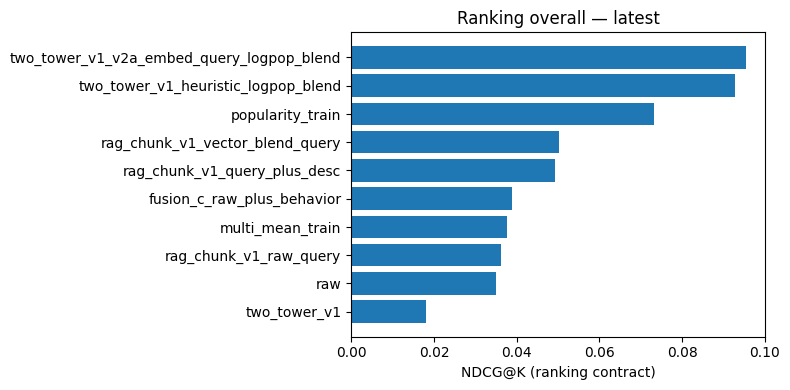

In [5]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is not None and rank_overall is not None and "NDCG@K" in rank_overall.columns:
    df = rank_overall.sort_values("NDCG@K", ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(df))))
    ax.barh(df["method"], df["NDCG@K"])
    ax.set_xlabel("NDCG@K (ranking contract)")
    ax.set_title(f"Ranking overall — {EVAL_RUN}")
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib not available or ranking table missing; tables above are enough.")